Amazon Customer Review Intelligence

NLP-Based Sentiment Analysis using Machine Learning

Author: Akriti Kachroo

Dataset: Kaggle Consumer Reviews of Amazon Products (34,000+ reviews)

Objective: Build a machine learning model that classifies Amazon reviews as Positive, Neutral, or Negative.

Table of Contents

1.Import Libraries

2.Load Dataset

3.Data Exploration

4.Data Cleaning

5.Feature Engineering

6.Exploratory Data Analysis

7.Model Building

8.Model Evaluation

9.Predict New Reviews

10.Business Insights

11.Save the Model

Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

from wordcloud import WordCloud

Upload Dataset (Colab)

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 1429_1.csv to 1429_1.csv


Load Dataset

Preview Data

In [ ]:
df = pd.read_csv("1429_1.csv", low_memory=False)

print("Dataset Shape:", df.shape)

Dataset Shape: (34660, 21)


Dataset Information

In [ ]:
df.head()

,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34660 entries, 0 to 34659
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    34660 non-null  object 
 1   name                  27900 non-null  object 
 2   asins                 34658 non-null  object 
 3   brand                 34660 non-null  object 
 4   categories            34660 non-null  object 
 5   keys                  34660 non-null  object 
 6   manufacturer          34660 non-null  object 
 7   reviews.date          34621 non-null  object 
 8   reviews.dateAdded     24039 non-null  object 
 9   reviews.dateSeen      34660 non-null  object 
 10  reviews.didPurchase   1 non-null      object 
 11  reviews.doRecommend   34066 non-null  object 
 12  reviews.id            1 non-null      float64
 13  reviews.numHelpful    34131 non-null  float64
 14  reviews.rating        34627 non-null  float64
 15  reviews.sourceURLs 

Data Cleaning

In [ ]:
# Keep only required columns
df = df[["name", "reviews.rating", "reviews.text"]]

# Remove missing values
df = df.dropna()

print("New Shape:", df.shape)

df.head()

New Shape: (27867, 3)


,name,reviews.rating,reviews.text
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,This product so far has not disappointed. My c...
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,great for beginner or experienced person. Boug...
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,Inexpensive tablet for him to use and learn on...
3,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",4.0,I've had my Fire HD 8 two weeks now and I love...
4,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,I bought this for my grand daughter when she c...


Create Sentiment Labels

In [ ]:
def sentiment_label(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

df["Sentiment"] = df["reviews.rating"].apply(sentiment_label)

df.head()

,name,reviews.rating,reviews.text,Sentiment
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,This product so far has not disappointed. My c...,Positive
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,great for beginner or experienced person. Boug...,Positive
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,Inexpensive tablet for him to use and learn on...,Positive
3,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",4.0,I've had my Fire HD 8 two weeks now and I love...,Positive
4,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,I bought this for my grand daughter when she c...,Positive


Create Sentiment Labels


In [ ]:
def sentiment_label(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

df["Sentiment"] = df["reviews.rating"].apply(sentiment_label)

df.head()

,name,reviews.rating,reviews.text,Sentiment
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,This product so far has not disappointed. My c...,Positive
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,great for beginner or experienced person. Boug...,Positive
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,Inexpensive tablet for him to use and learn on...,Positive
3,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",4.0,I've had my Fire HD 8 two weeks now and I love...,Positive
4,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,I bought this for my grand daughter when she c...,Positive


Count Sentiments


In [ ]:
df["Sentiment"].value_counts()

,count
Sentiment,
Positive,25913
Neutral,1289
Negative,665


Sentiment Distribution Chart


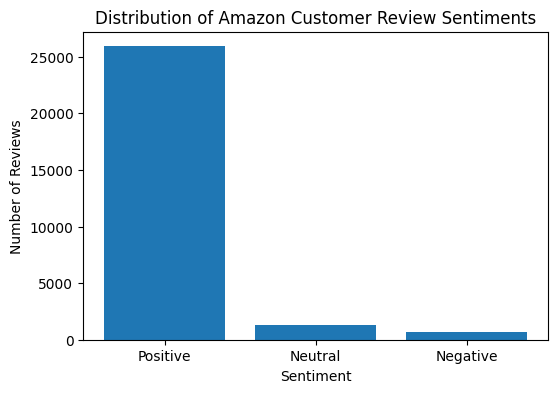

In [ ]:
sentiment_counts = df["Sentiment"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.title("Distribution of Amazon Customer Review Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

Star Rating Distribution


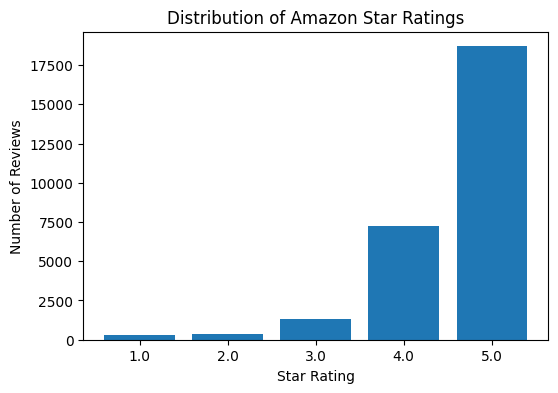

In [ ]:
rating_counts = df["reviews.rating"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(rating_counts.index.astype(str), rating_counts.values)
plt.title("Distribution of Amazon Star Ratings")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.show()

Top 10 Most Reviewed Products


) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


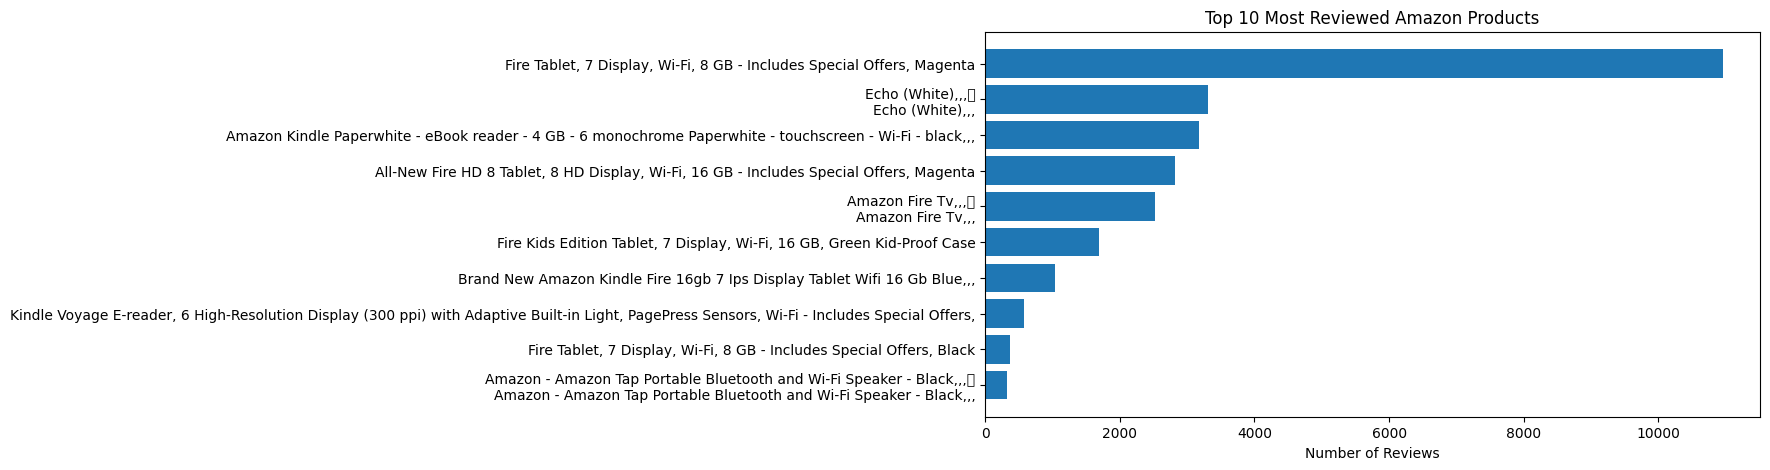

In [ ]:
top_products = df["name"].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.barh(top_products.index, top_products.values)
plt.title("Top 10 Most Reviewed Amazon Products")
plt.xlabel("Number of Reviews")
plt.gca().invert_yaxis()
plt.show()

Split the Data


In [ ]:
X = df["reviews.text"]
y = df["Sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 22293
Testing samples: 5574


TF-IDF Vectorization


In [ ]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)

(22293, 5000)


Train Logistic Regression Model


In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

print("Model trained successfully!")

Model trained successfully!


Make Predictions


In [ ]:
predictions = model.predict(X_test_tfidf)

predictions[:10]

array(['Positive', 'Positive', 'Positive', 'Positive', 'Positive',
       'Positive', 'Positive', 'Positive', 'Positive', 'Positive'],
      dtype=object)

Model Accuracy


In [ ]:
accuracy = accuracy_score(y_test, predictions)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 93.33%


Classification Report


In [ ]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

    Negative       0.58      0.11      0.19       133
     Neutral       0.50      0.06      0.11       258
    Positive       0.94      1.00      0.97      5183

    accuracy                           0.93      5574
   macro avg       0.67      0.39      0.42      5574
weighted avg       0.91      0.93      0.91      5574



Confusion Matrix


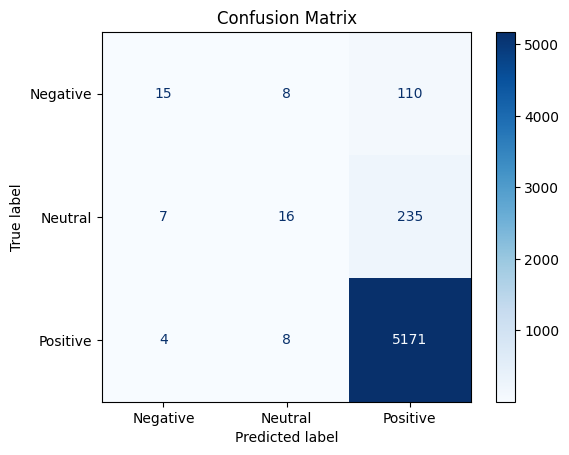

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

Predict New Reviews


In [ ]:
def predict_sentiment(review):
    review_vector = vectorizer.transform([review])
    prediction = model.predict(review_vector)[0]
    return prediction

Positive Word Cloud


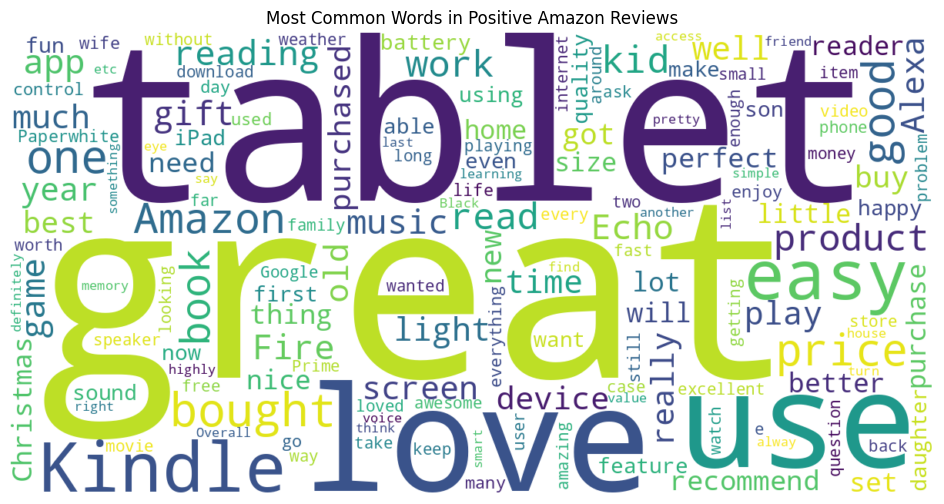

In [ ]:
positive_text = " ".join(
    df[df["Sentiment"] == "Positive"]["reviews.text"].astype(str)
)

positive_wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=150,
    collocations=False
).generate(positive_text)

plt.figure(figsize=(12,6))
plt.imshow(positive_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Positive Amazon Reviews")

plt.savefig("positive_wordcloud.png", dpi=300, bbox_inches="tight")

plt.show()

Negative Word Cloud


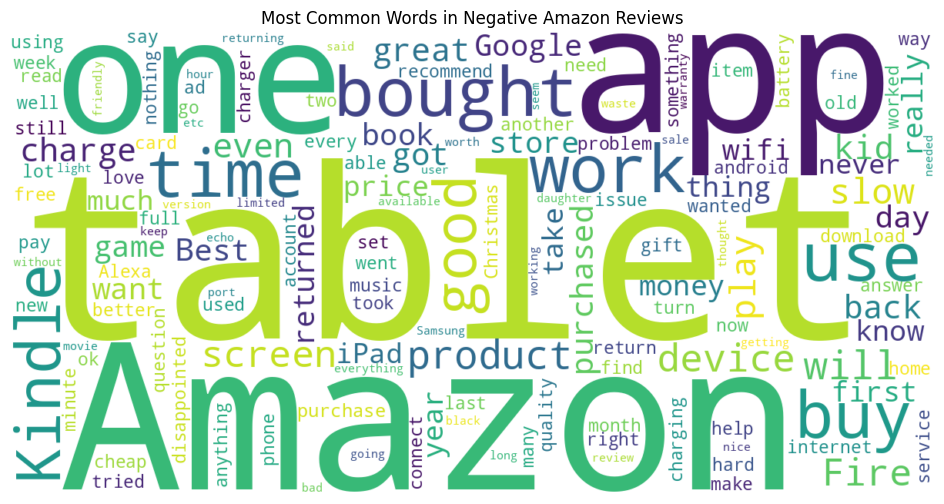

In [ ]:
negative_text = " ".join(
    df[df["Sentiment"] == "Negative"]["reviews.text"].astype(str)
)

negative_wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=150,
    collocations=False
).generate(negative_text)

plt.figure(figsize=(12,6))
plt.imshow(negative_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Negative Amazon Reviews")

plt.savefig("negative_wordcloud.png", dpi=300, bbox_inches="tight")

plt.show()

Test Multiple Reviews


In [ ]:
tests = [
    "This tablet is amazing and works perfectly!",
    "The battery died after one day.",
    "I want a refund.",
    "It's okay, nothing special."
]

for review in tests:
    print(f"{review}\n→ {predict_sentiment(review)}\n")

This tablet is amazing and works perfectly!
→ Positive

The battery died after one day.
→ Positive

I want a refund.
→ Positive

It's okay, nothing special.
→ Positive



Save Model


In [ ]:
with open("sentiment_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


Save Sentiment Distribution Graph

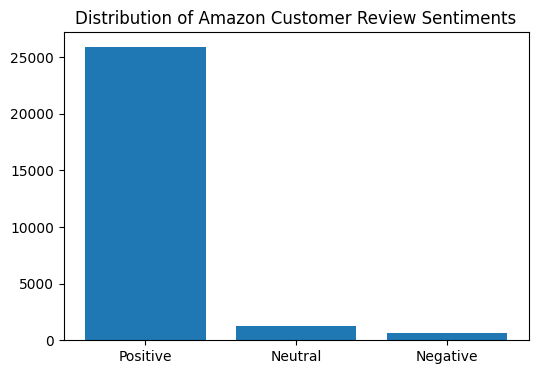

In [ ]:

plt.figure(figsize=(6,4))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.title("Distribution of Amazon Customer Review Sentiments")

plt.savefig("sentiment_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [32]:
from google.colab import files

for file in [
    "sentiment_model.pkl",
    "tfidf_vectorizer.pkl",
    "confusion_matrix.png",
    "positive_wordcloud.png",
    "negative_wordcloud.png",
    "sentiment_distribution.png"
]:
    files.download(file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>